In [1]:
import atom
import matplotlib.pyplot as plt
import mrcfile
import pdbtools
import potential
import propagators
import torch
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

## Plotting functions

In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.5), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    plt.suptitle(f"Slices along axis {axis}")
    plt.show()

## Download PDB file

In [3]:
folder = './pdb-data/'
filename = pdbtools.fetch_pdb_file("5mac", output=folder)
filename

PDB file saved to: ./pdb-data/5mac.cif


'./pdb-data/5mac.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [15]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

(torch.Size([37866]), torch.Size([37866, 3]))

In [16]:
atomic_numbers

tensor([7, 6, 6,  ..., 8, 8, 8])

In [17]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'CL', 'P', 'O', 'C', 'N', 'MG', 'S'}


In [19]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Compute volumetric potential from PDB (2D Projection, Snap)

In [21]:
dx = 1
n = 256
super_sampling_factor = 4
vol_snapped_2d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-2d",
)

37866it [00:04, 9231.04it/s]


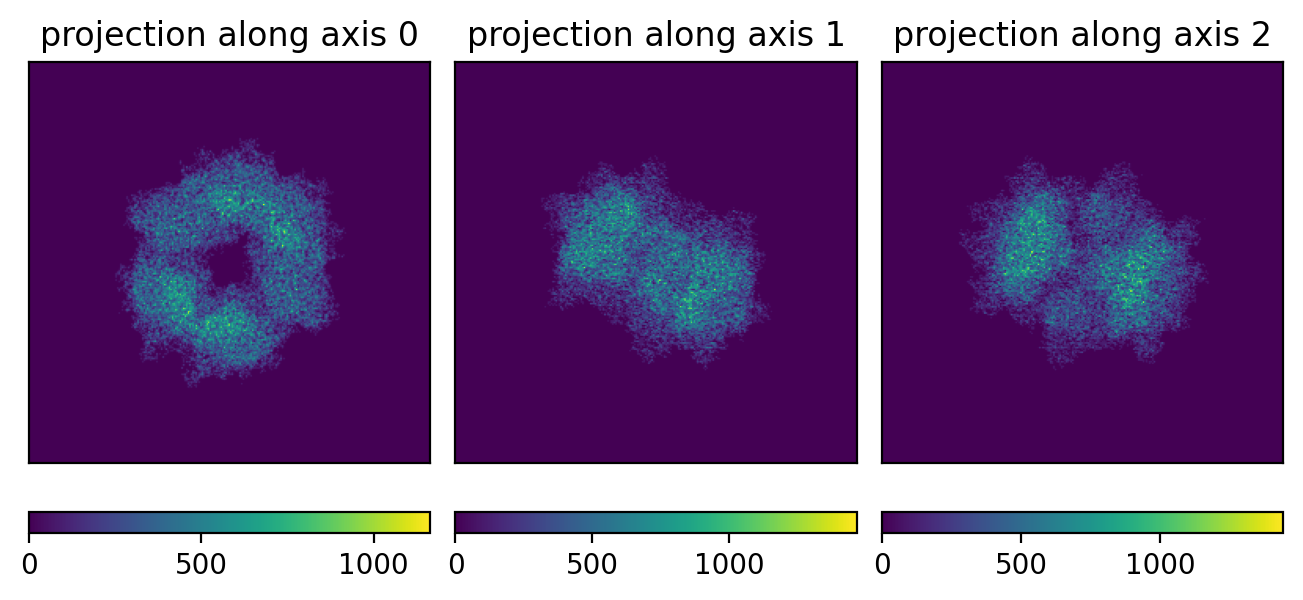

In [22]:
plot3d(vol_snapped_2d)

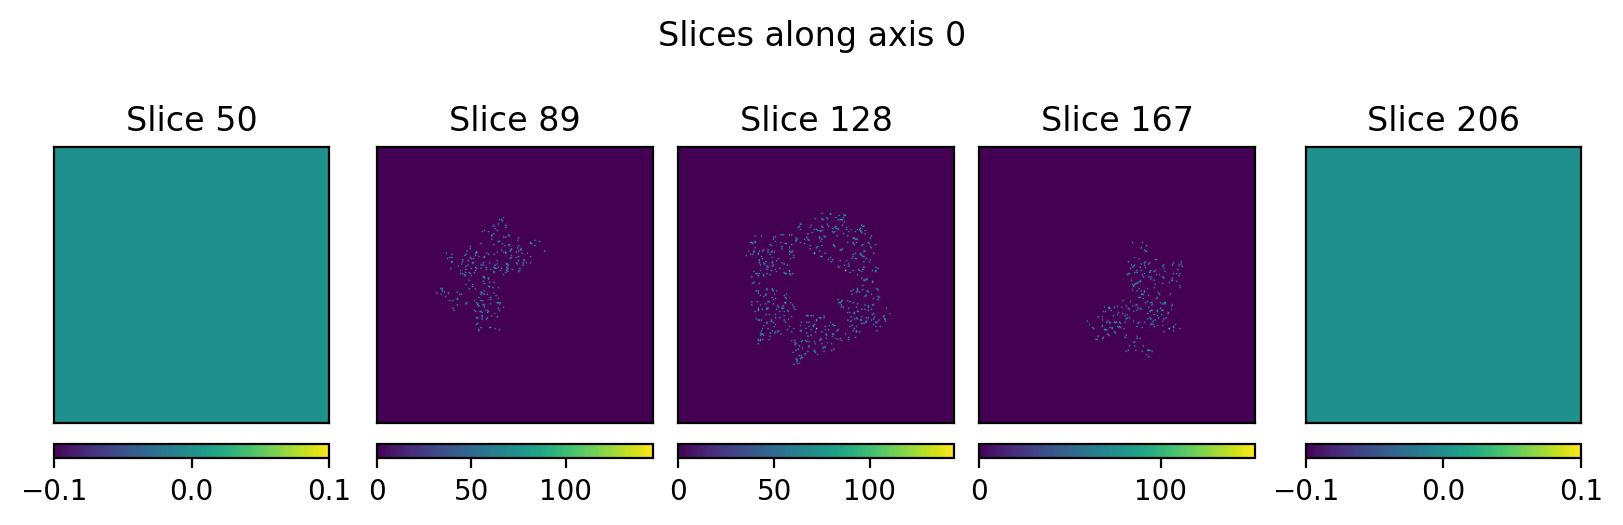

In [23]:
start_idx = 50
plot_slices(vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [24]:
vol_snapped_3d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

37866it [00:04, 8402.87it/s]


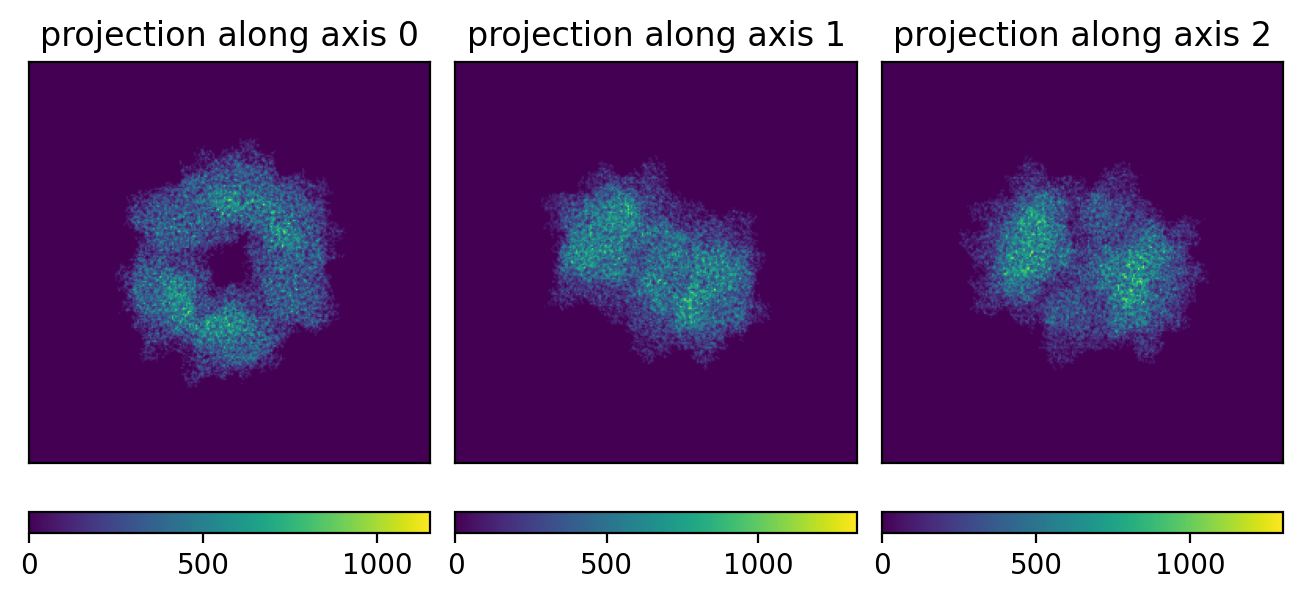

In [25]:
plot3d(vol_snapped_3d)

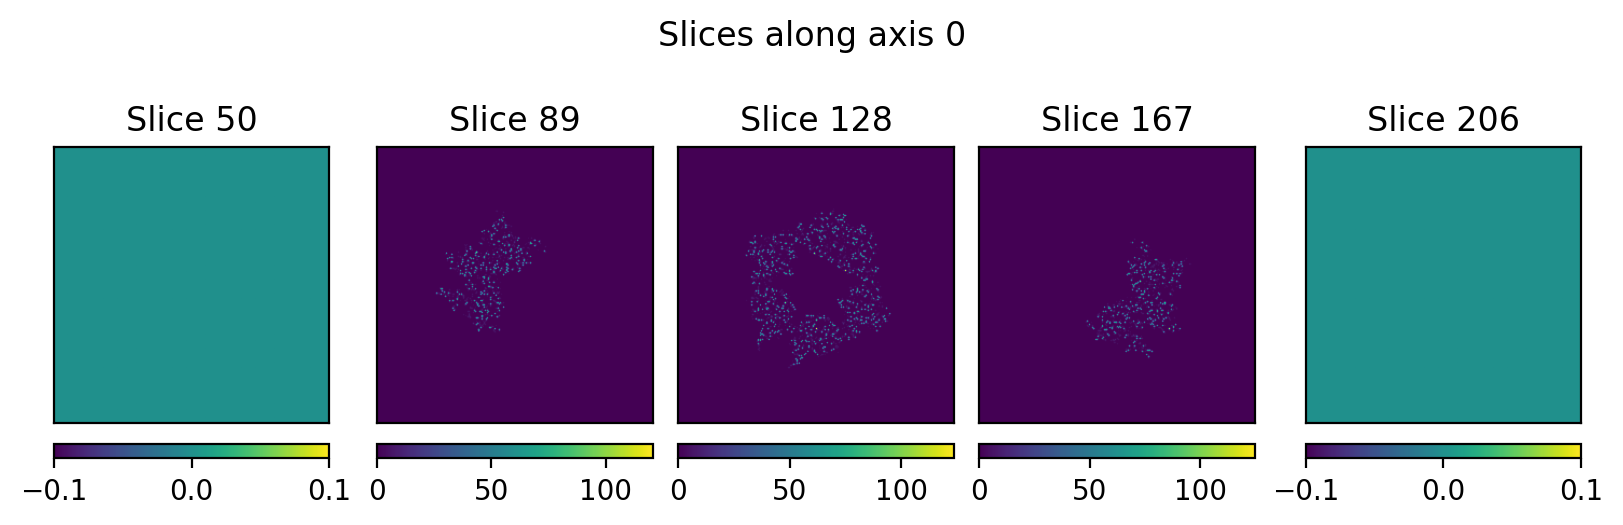

In [26]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [27]:
vol_2d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

37866it [02:01, 311.96it/s]


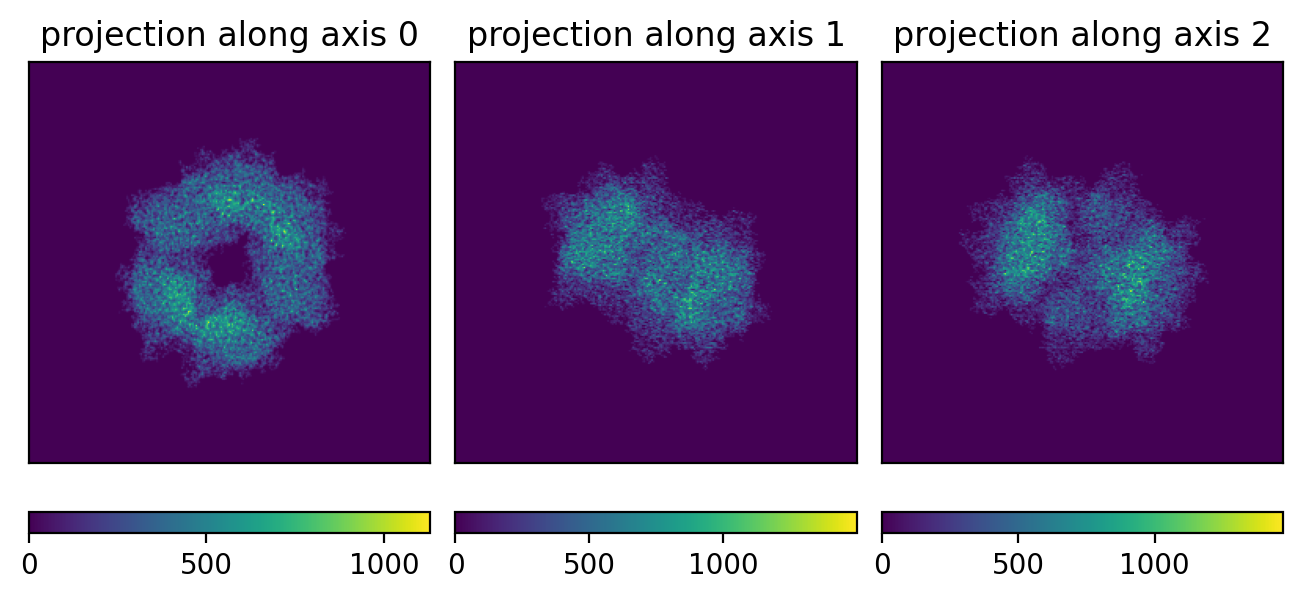

In [28]:
plot3d(vol_2d)

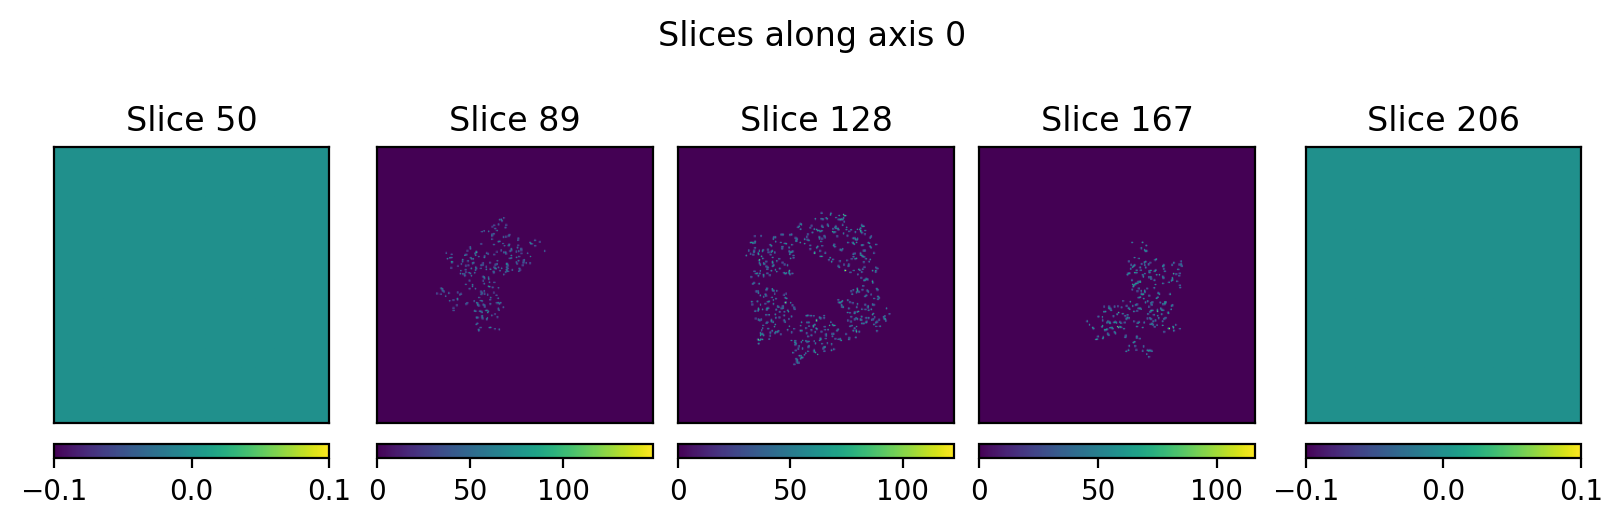

In [29]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [30]:
vol_3d = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

37866it [02:14, 280.98it/s]


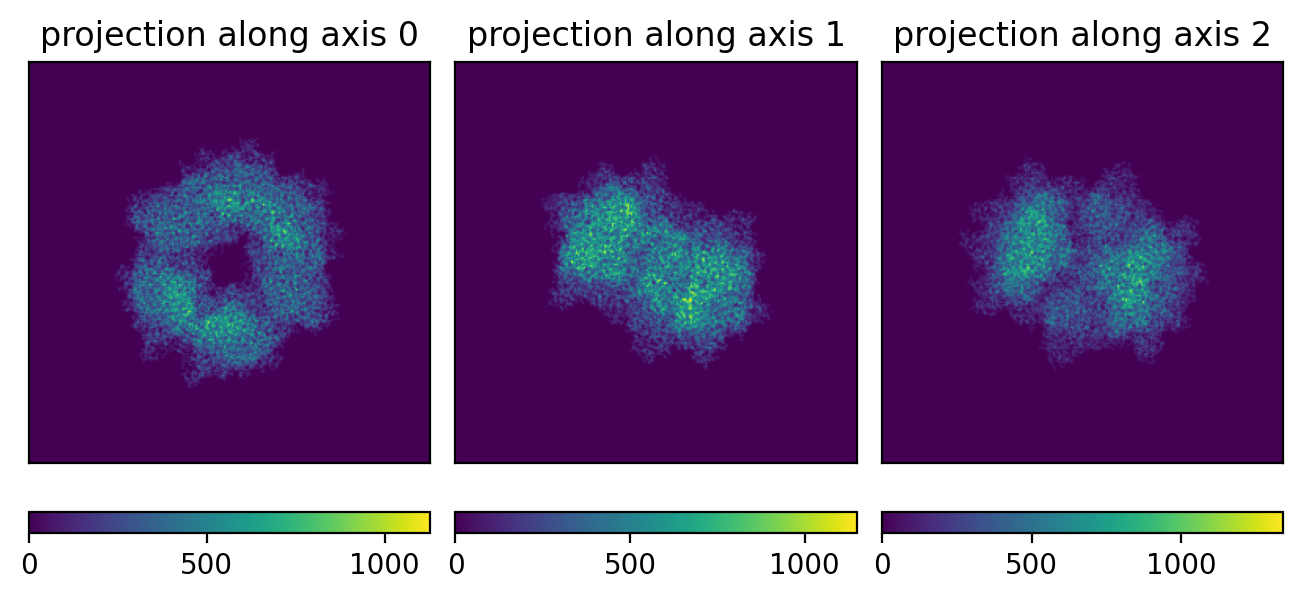

In [31]:
plot3d(vol_3d)

## Compare error between snap and no-snap

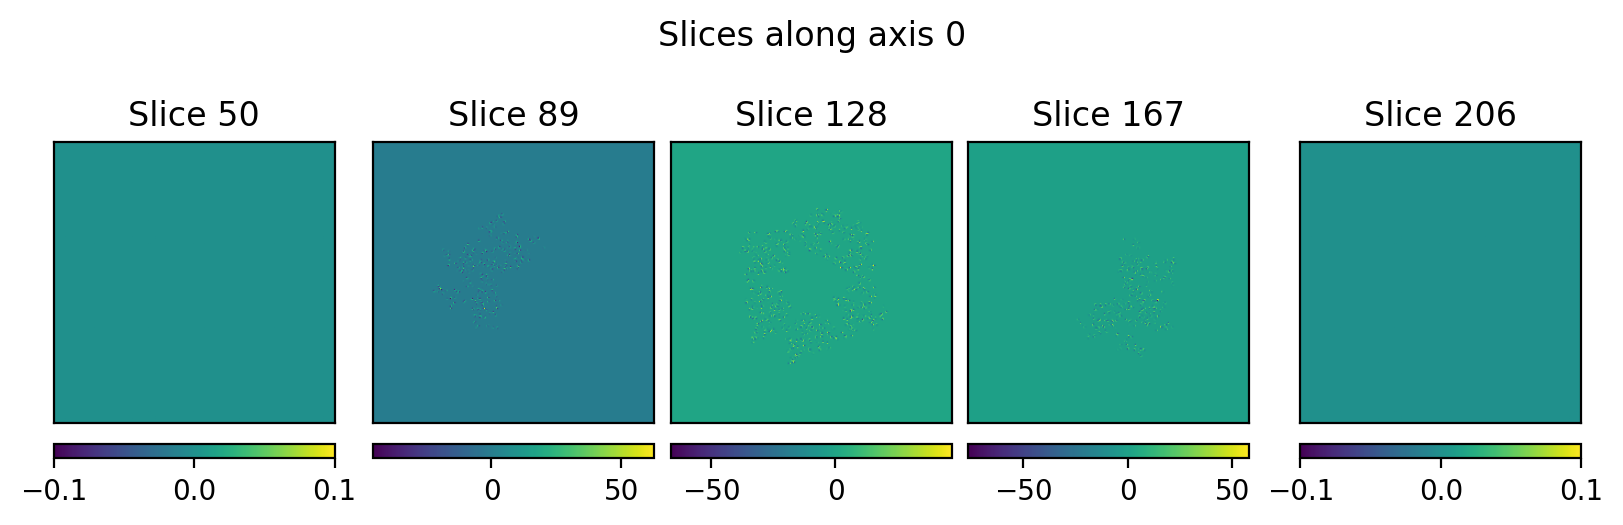

In [32]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

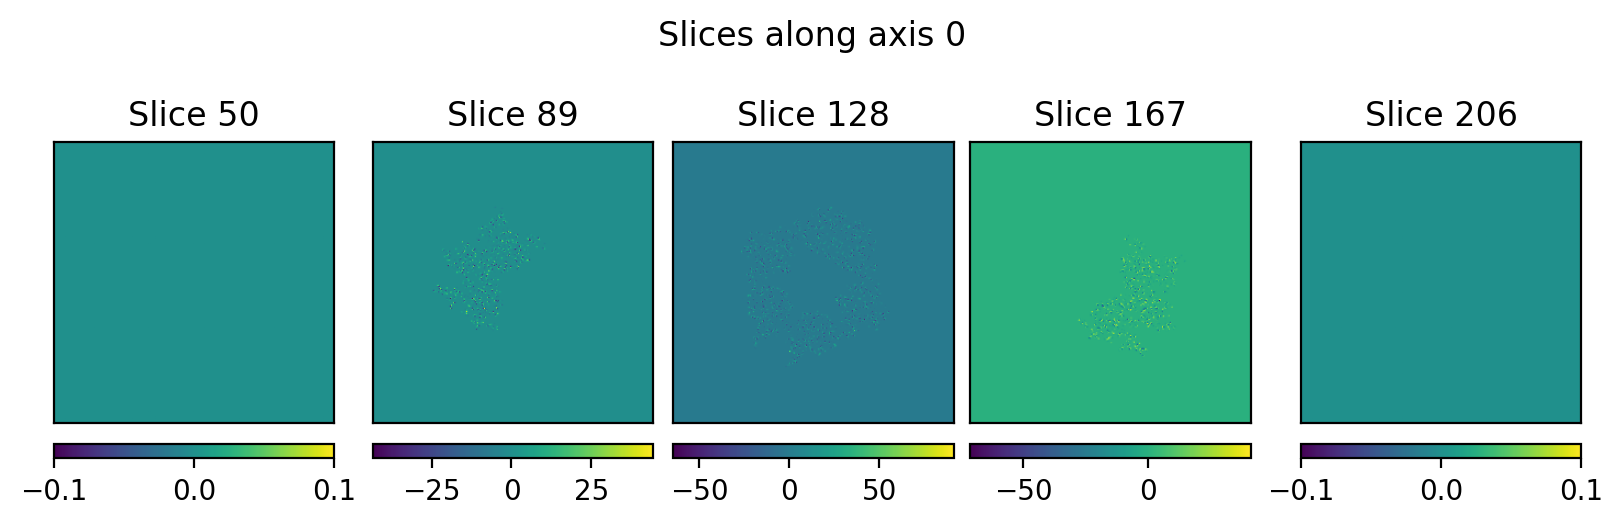

In [33]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Solvate

In [299]:
ice_atomic_numbers, ice_coordinates = ice.volume_of_ice(n_xyz=(n,n,n), d_xyz=(dx,dx,dx))

527178


In [300]:
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume(
    ice_atomic_numbers,
    ice_coordinates,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=31,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

1581534it [02:55, 9010.26it/s]


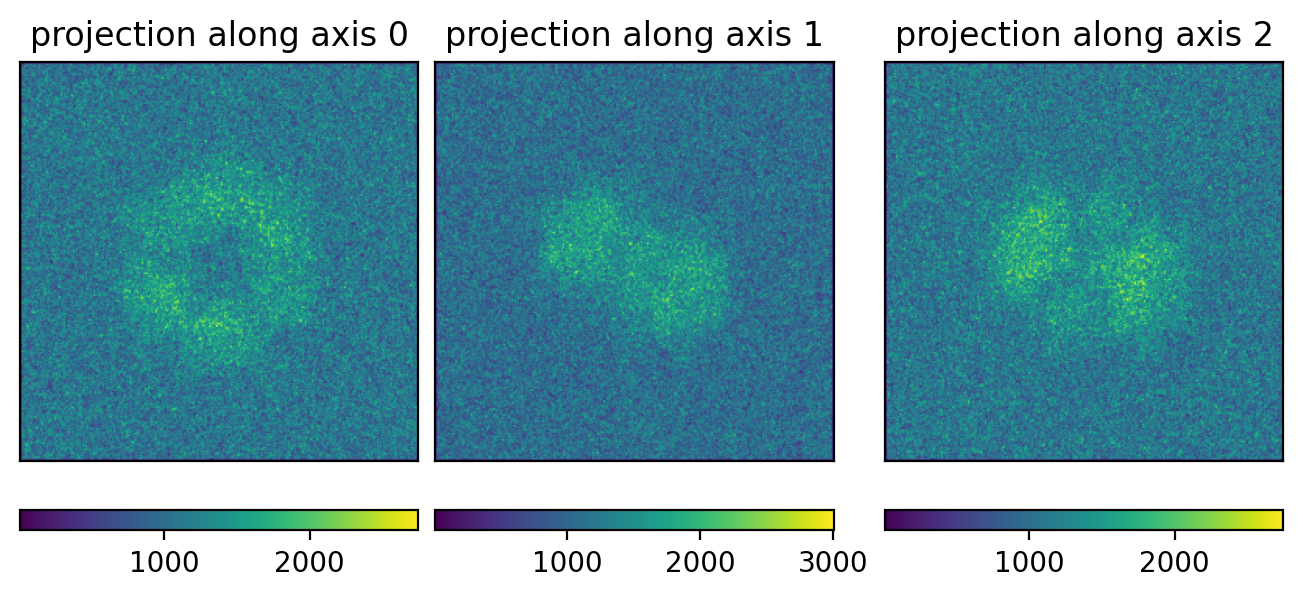

In [301]:
plot3d(ice_vol_3d + vol_3d)

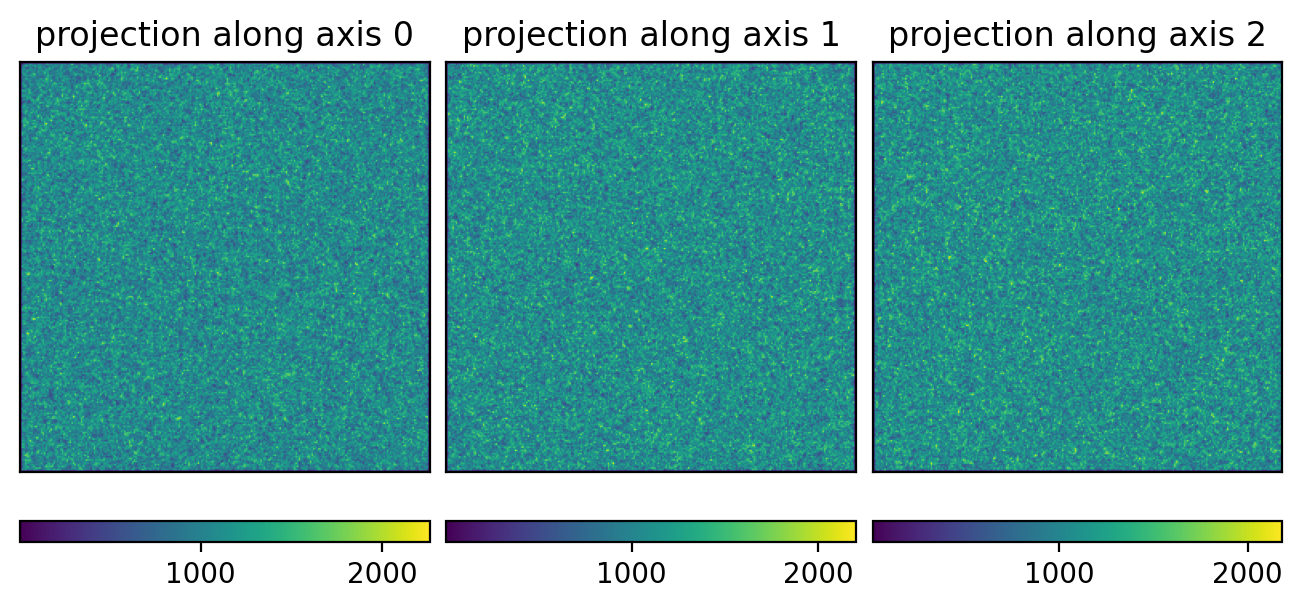

In [302]:
plot3d(ice_vol_3d)

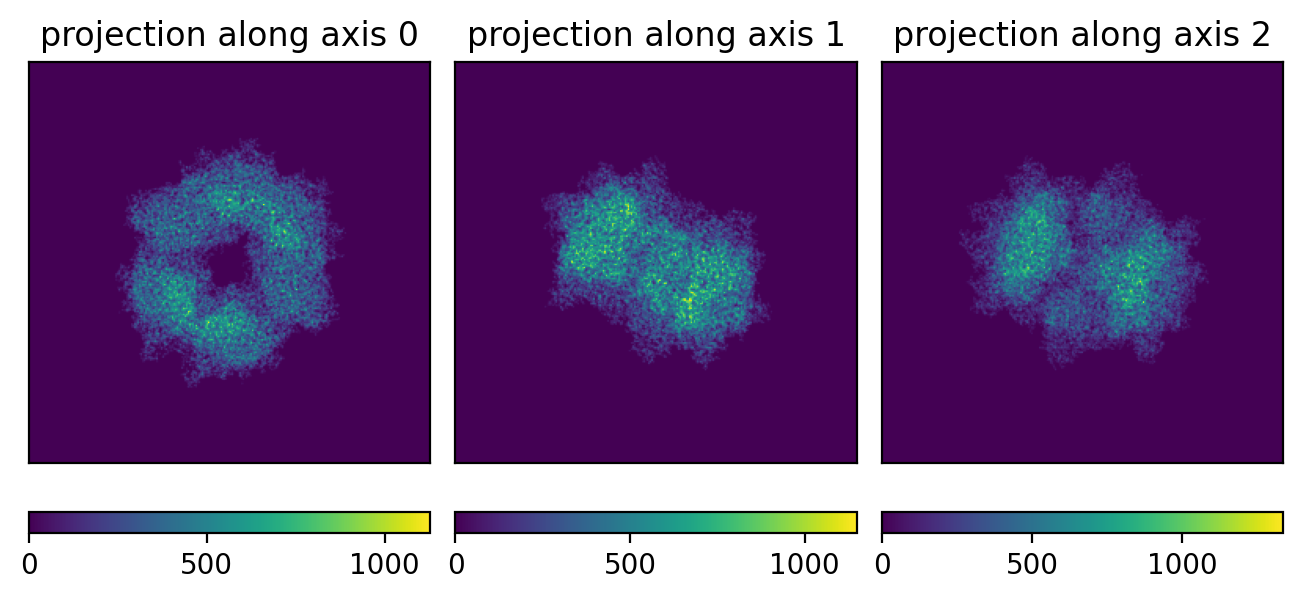

In [303]:
plot3d(vol_3d)